In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile
import os

zip_path     = '/content/drive/MyDrive/12-way script classification dataset-20260320T081258Z-3-001.zip'
extract_path = '/content/dataset'

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction done")
print(os.listdir(extract_path))

Extraction done
['12-way script classification dataset']


In [ ]:
!pip install tensorflow keras-hub scikit-learn seaborn matplotlib pillow -q

In [ ]:
import os

extract_path = '/content/dataset'

for root, dirs, files in os.walk(extract_path):
    level = root.replace(extract_path, '').count(os.sep)
    if level < 3:
        print(' ' * 2 * level + os.path.basename(root) + '/')

dataset/
  12-way script classification dataset/
    test_478/
    train_1800/


In [ ]:
train_dir = '/content/dataset/12-way script classification dataset/train_1800'
test_dir  = '/content/dataset/12-way script classification dataset/test_478'

print("Train classes:", sorted(os.listdir(train_dir)))
print("Test classes :", sorted(os.listdir(test_dir)))

Train classes: ['assamese', 'bengali', 'english', 'gujarati', 'hindi', 'kannada', 'malayalam', 'marathi', 'odia', 'punjabi', 'tamil', 'telugu']
Test classes : ['assamese', 'bengali', 'english', 'gujarati', 'hindi', 'kannada', 'malayalam', 'marathi', 'odia', 'punjabi', 'tamil', 'telugu']


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import keras_hub
from sklearn.metrics import classification_report, confusion_matrix
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print("GPU enabled:", gpus)
else:
    print("No GPU - go to Runtime > Change runtime type > T4 GPU")

print("TensorFlow:", tf.__version__)
print("Keras Hub :", keras_hub.__version__)

GPU enabled: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
TensorFlow: 2.19.0
Keras Hub : 0.26.0


In [ ]:
from tensorflow.keras import mixed_precision

policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)
print("Mixed precision:", policy.name)

Mixed precision: mixed_float16


In [ ]:
train_dir   = '/content/dataset/12-way script classification dataset/train_1800'
test_dir    = '/content/dataset/12-way script classification dataset/test_478'

IMG_SIZE    = 224
BATCH_SIZE  = 32
NUM_CLASSES = 12
SEED        = 42
LR          = 1e-3

np.random.seed(SEED)
tf.random.set_seed(SEED)

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

def load_and_preprocess(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

def build_dataset(data_dir, training=True):
    data_dir   = Path(data_dir)
    class_dirs = sorted([d for d in data_dir.iterdir() if d.is_dir()])
    cls_names  = [d.name for d in class_dirs]
    cls_to_idx = {name: idx for idx, name in enumerate(cls_names)}

    all_paths, all_labels = [], []

    for class_dir in class_dirs:
        label = cls_to_idx[class_dir.name]
        for img_path in class_dir.glob('*'):
            if img_path.suffix.lower() in ['.jpg', '.jpeg', '.png', '.bmp']:
                all_paths.append(str(img_path))
                all_labels.append(label)

    all_paths  = np.array(all_paths)
    all_labels = np.array(all_labels)

    idx        = np.random.permutation(len(all_paths))
    all_paths  = all_paths[idx]
    all_labels = all_labels[idx]

    if training:
        split      = int(0.9 * len(all_paths))
        tr_paths   = all_paths[:split]
        val_paths  = all_paths[split:]
        tr_labels  = all_labels[:split]
        val_labels = all_labels[split:]

        tr_labels_oh  = tf.keras.utils.to_categorical(tr_labels,  NUM_CLASSES)
        val_labels_oh = tf.keras.utils.to_categorical(val_labels, NUM_CLASSES)

        train_ds = (tf.data.Dataset.from_tensor_slices((tr_paths, tr_labels_oh))
                    .shuffle(len(tr_paths), seed=SEED)
                    .map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
                    .batch(BATCH_SIZE)
                    .prefetch(AUTOTUNE))

        val_ds   = (tf.data.Dataset.from_tensor_slices((val_paths, val_labels_oh))
                    .map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
                    .batch(BATCH_SIZE)
                    .prefetch(AUTOTUNE))

        return train_ds, val_ds, cls_names, tr_labels, val_labels

    else:
        labels_oh = tf.keras.utils.to_categorical(all_labels, NUM_CLASSES)

        test_ds  = (tf.data.Dataset.from_tensor_slices((all_paths, labels_oh))
                    .map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
                    .batch(BATCH_SIZE)
                    .prefetch(AUTOTUNE))

        return test_ds, cls_names, all_labels


train_ds, val_ds, class_names, train_labels, val_labels = build_dataset(train_dir, training=True)
test_ds,  _,      true_labels                           = build_dataset(test_dir,  training=False)

print("Classes    :", class_names)
print("Train size :", len(train_labels))
print("Val size   :", len(val_labels))
print("Test size  :", len(true_labels))
print("Train steps:", len(train_labels) // BATCH_SIZE)

Classes    : ['assamese', 'bengali', 'english', 'gujarati', 'hindi', 'kannada', 'malayalam', 'marathi', 'odia', 'punjabi', 'tamil', 'telugu']
Train size : 19440
Val size   : 2160
Test size  : 5736
Train steps: 607


In [ ]:
backbone = keras_hub.models.ViTBackbone.from_preset(
    "vit_base_patch16_224_imagenet"
)

backbone.trainable = False
print("Pretrained ViT backbone loaded and frozen")

Pretrained ViT backbone loaded and frozen


In [ ]:
def build_model(learning_rate=LR, dropout=0.3, trainable_backbone=False):

    backbone.trainable = trainable_backbone

    inputs    = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x         = backbone(inputs, training=False)

    # CLS token at index 0
    cls_token = x[:, 0, :]

    x = layers.LayerNormalization()(cls_token)
    x = layers.Dense(512, activation='gelu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(256, activation='gelu')(x)
    x = layers.Dropout(dropout * 0.5)(x)

    # float32 for mixed precision stability
    outputs = layers.Dense(NUM_CLASSES, activation='softmax', dtype='float32')(x)

    model = keras.Model(inputs=inputs, outputs=outputs)

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


model = build_model()
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vi_t_backbone (ViTBackbone)     │ (None, 197, 768)       │    85,798,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ get_item (GetItem)              │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization             │ (None, 768)            │         1,536 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       393,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 12)             │         3,084 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 86,330,380 (329.32 MB)

 Trainable params: 530,700 (2.02 MB)

 Non-trainable params: 85,799,680 (327.30 MB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

def get_callbacks(name):
    return [
        EarlyStopping(
            monitor='val_accuracy',
            patience=5,
            restore_best_weights=True,
            verbose=1
        ),
        ModelCheckpoint(
            name,
            monitor='val_accuracy',
            save_best_only=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=3,
            min_lr=1e-8,
            verbose=1
        )
    ]

print("Callbacks ready")

Callbacks ready


In [ ]:
configs = [
    {'lr': 3e-4, 'dropout': 0.2, 'trainable': False},
    {'lr': 1e-4, 'dropout': 0.3, 'trainable': False},
    {'lr': 5e-5, 'dropout': 0.2, 'trainable': True},
]

results = []

for i, cfg in enumerate(configs):
    print(f"\nConfig {i+1}: {cfg}")
    print("-" * 45)

    m = build_model(
        learning_rate=cfg['lr'],
        dropout=cfg['dropout'],
        trainable_backbone=cfg['trainable']
    )
    m.compile(
    optimizer=keras.optimizers.Adam(learning_rate=cfg['lr']),
    loss='categorical_crossentropy',
    metrics=['accuracy']
        )

    hist = m.fit(
        train_ds,
        epochs=8,
        validation_data=val_ds,
        callbacks=get_callbacks(f'tune_{i+1}.keras'),
        verbose=1
    )

    best_val = max(hist.history['val_accuracy'])
    results.append({'config': cfg, 'val_acc': best_val, 'model': m})
    print(f"Config {i+1} best val acc: {best_val*100:.2f}%")

best       = max(results, key=lambda x: x['val_acc'])
best_model = best['model']
print("\nBest config :", best['config'])
print("Best val acc:", f"{best['val_acc']*100:.2f}%")


Config 1: {'lr': 0.0003, 'dropout': 0.2, 'trainable': False}
---------------------------------------------
Epoch 1/8
608/608 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 0.3347 - loss: 1.9980
Epoch 1: val_accuracy improved from None to 0.58796, saving model to tune_1.keras

Epoch 1: finished saving model to tune_1.keras
608/608 ━━━━━━━━━━━━━━━━━━━━ 109s 139ms/step - accuracy: 0.4339 - loss: 1.6644 - val_accuracy: 0.5880 - val_loss: 1.2011 - learning_rate: 3.0000e-04
Epoch 2/8
608/608 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.6074 - loss: 1.1304
Epoch 2: val_accuracy improved from 0.58796 to 0.61250, saving model to tune_1.keras

Epoch 2: finished saving model to tune_1.keras
608/608 ━━━━━━━━━━━━━━━━━━━━ 75s 123ms/step - accuracy: 0.6176 - loss: 1.1094 - val_accuracy: 0.6125 - val_loss: 1.1039 - learning_rate: 3.0000e-04
Epoch 3/8
608/608 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.6835 - loss: 0.9220
Epoch 3: val_accuracy improved from 0.61250 to 0.64676, saving model to

180/180 ━━━━━━━━━━━━━━━━━━━━ 23s 128ms/step - accuracy: 0.8297 - loss: 0.7200

Final Test Accuracy: 82.97%
180/180 ━━━━━━━━━━━━━━━━━━━━ 28s 132ms/step

Final Class-wise Accuracy:
-----------------------------------
  assamese            : 78.66%
  bengali             : 73.01%
  english             : 92.05%
  gujarati            : 92.05%
  hindi               : 74.48%
  kannada             : 85.36%
  malayalam           : 83.47%
  marathi             : 63.81%
  odia                : 89.75%
  punjabi             : 91.00%
  tamil               : 85.98%
  telugu              : 85.98%
-----------------------------------
  Mean Accuracy: 82.97%

Full Classification Report:
              precision    recall  f1-score   support

    assamese     0.7475    0.7866    0.7666       478
     bengali     0.7950    0.7301    0.7612       478
     english     0.8853    0.9205    0.9026       478
    gujarati     0.8961    0.9205    0.9082       478
       hindi     0.6629    0.7448    0.7015       478

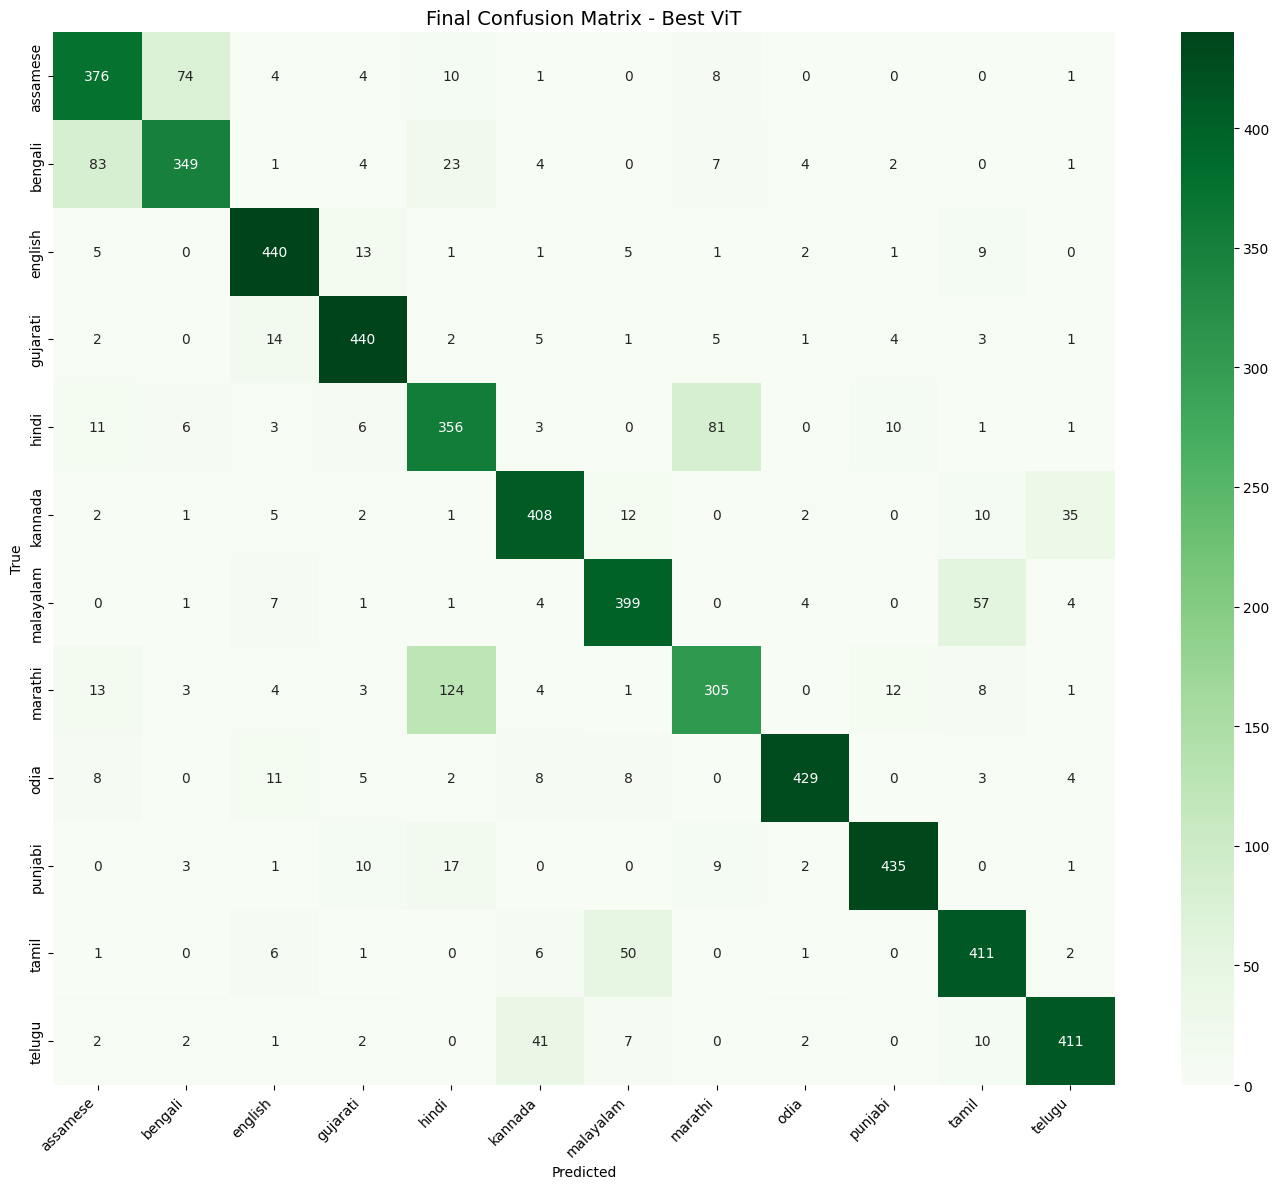

In [ ]:
test_loss, test_acc = best_model.evaluate(test_ds, verbose=1)
print(f"\nFinal Test Accuracy: {test_acc*100:.2f}%")

y_pred_final = np.argmax(best_model.predict(test_ds, verbose=1), axis=1)
y_true_final = true_labels

cm_final    = confusion_matrix(y_true_final, y_pred_final)
class_acc_f = cm_final.diagonal() / cm_final.sum(axis=1)

print("\nFinal Class-wise Accuracy:")
print("-" * 35)
for name, acc in zip(class_names, class_acc_f):
    print(f"  {name:20s}: {acc*100:.2f}%")
print("-" * 35)
print(f"  Mean Accuracy: {class_acc_f.mean()*100:.2f}%")

print("\nFull Classification Report:")
print(classification_report(y_true_final, y_pred_final, target_names=class_names, digits=4))

plt.figure(figsize=(14, 12))
sns.heatmap(
    cm_final,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title('Final Confusion Matrix - Best ViT', fontsize=14)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('final_confusion_matrix.png', dpi=150)
plt.show()